In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
data = pd.read_csv('../RH_dataset.csv', sep=';')

data.head()

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


Quelles sont les colonnes ?

In [10]:
data.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')

Exhiber le parcours d'un employé qui a démissionné : classe 1.

In [18]:
resigned_employees = data[data['label'] == 1]
resigned_employee_parcours = resigned_employees.iloc[0]
print(resigned_employee_parcours)

Famille d'emploi                 Production
Dernière promotion (mois)              5.24
Dernière augmentation (mois)            5.1
Début de contrat (années)              1.02
Ancienneté groupe (années)             1.75
Etablissement                            27
Âge (années)                             24
Parent                                    0
Niveau hiérarchique                       1
Salaire (Euros)                        2641
Statut marital                  Célibataire
Véhicule                                  0
matricule                              2619
label                                     1
Name: 3, dtype: object


Moyenne des personnes qui ont démissionné :

In [28]:
resigned_employee_parcours_mean = (
    resigned_employees
    .select_dtypes(exclude=['object', 'string'])
    .mean()
)

resigned_employee_parcours_mean.drop(columns=['Etablissement', 'matricule', 'label'])

resigned_employee_parcours_mean

Dernière promotion (mois)         23.845894
Dernière augmentation (mois)       8.060728
Début de contrat (années)          4.673563
Ancienneté groupe (années)         6.245868
Etablissement                     18.950993
Âge (années)                      35.270199
Parent                             0.484768
Niveau hiérarchique                1.344371
Salaire (Euros)                 3635.705960
Véhicule                           0.324503
matricule                       1365.797351
label                              1.000000
dtype: float64

Exhiber le parcours d'un employé qui n'a pas démissionné : classe 0.

In [30]:
not_resigned_employees = data[data['label'] == 0]
not_resigned_employee_parcours = not_resigned_employees.iloc[0]
print(not_resigned_employee_parcours)

Famille d'emploi                Production
Dernière promotion (mois)             8.51
Dernière augmentation (mois)           7.9
Début de contrat (années)             0.91
Ancienneté groupe (années)            0.97
Etablissement                           27
Âge (années)                            30
Parent                                   1
Niveau hiérarchique                      1
Salaire (Euros)                       3199
Statut marital                    Marié(e)
Véhicule                                 0
matricule                               32
label                                    0
Name: 0, dtype: object


Moyenne des personnes qui n'ont pas démissionné :

In [36]:
not_resigned_employee_parcours_mean = (
    not_resigned_employees
    .select_dtypes(exclude=['object', 'string'])
    .mean()
)

not_resigned_employee_parcours_mean.drop(columns=['Etablissement', 'matricule', 'label'])

not_resigned_employee_parcours_mean

Dernière promotion (mois)         29.644239
Dernière augmentation (mois)       7.930876
Début de contrat (années)          7.623685
Ancienneté groupe (années)        11.808123
Etablissement                     20.234568
Âge (années)                      41.979482
Parent                             0.728422
Niveau hiérarchique                1.561423
Salaire (Euros)                 4185.813220
Véhicule                           0.512813
matricule                       1361.107437
label                              0.000000
dtype: float64

In [40]:
counts = (
    data
    .groupby('label')['Statut marital']
    .value_counts()
    .unstack(fill_value=0)
)

counts

Statut marital,Concubin,Célibataire,Divorcé(e),Marié(e),PACS,Séparé(e),Union libre,Veuf(ve),ex PACS
label,,,,,,,,,
0,1015,4825,1120,9999,4434,480,983,163,83
1,38,286,21,252,122,8,26,2,0


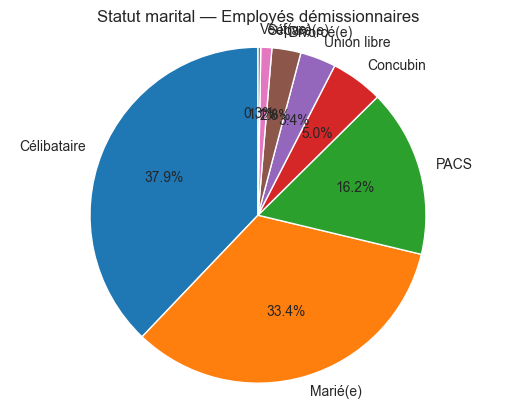

In [42]:
resigned_counts = (
    data[data['label'] == 1]['Statut marital']
    .value_counts()
)

plt.figure()
plt.pie(
    resigned_counts,
    labels=resigned_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Statut marital — Employés démissionnaires")
plt.axis('equal')  # cercle parfait
plt.show()

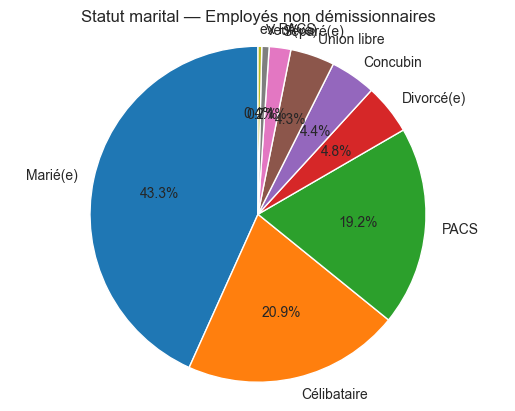

In [43]:
not_resigned_counts = (
    data[data['label'] == 0]['Statut marital']
    .value_counts()
)

plt.figure()
plt.pie(
    not_resigned_counts,
    labels=not_resigned_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Statut marital — Employés non démissionnaires")
plt.axis('equal')
plt.show(

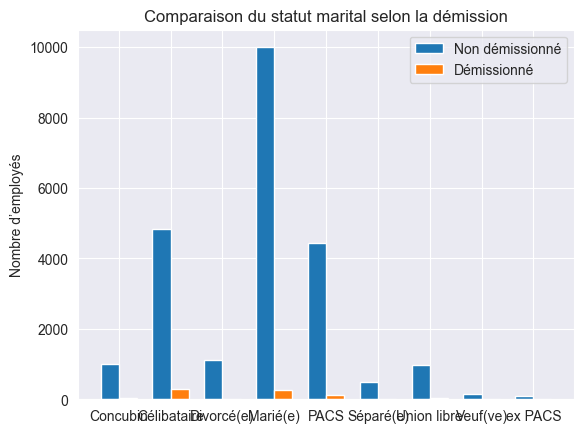

In [44]:
import numpy as np

labels = counts.columns
x = np.arange(len(labels))
width = 0.35

plt.figure()

plt.bar(x - width/2, counts.loc[0], width, label='Non démissionné')
plt.bar(x + width/2, counts.loc[1], width, label='Démissionné')

plt.xticks(x, labels)
plt.ylabel('Nombre d’employés')
plt.title('Comparaison du statut marital selon la démission')
plt.legend()

plt.show()